In [1]:
# ============================================================
# PHASE 8: EXPERIMENT TRACKING — No MLflow needed
# We build a simple but professional experiment tracker
# that logs every run to a CSV and JSON file
# Same concept as MLflow — just no external dependencies
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, f1_score,
    precision_score, recall_score,
    confusion_matrix, roc_curve
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
import joblib, os, json
from datetime import datetime

# Load data
X_train = pd.read_csv('../data/processed/X_train_fe.csv')
X_test  = pd.read_csv('../data/processed/X_test_fe.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Create experiment log directory
os.makedirs('../experiment_logs', exist_ok=True)
os.makedirs('../reports/figures', exist_ok=True)
os.makedirs('../models', exist_ok=True)

print("Setup complete.")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

Setup complete.
X_train : (5634, 32)
X_test  : (1409, 32)


In [2]:
# ============================================================
# EXPERIMENT TRACKER
# Logs every run to: experiment_logs/experiment_log.csv
# This is exactly what MLflow does internally — we just
# build a lightweight version ourselves
# ============================================================

class ExperimentTracker:
    """
    Tracks ML experiments by logging params and metrics
    to a CSV file. Mimics core MLflow functionality.
    """

    def __init__(self, log_path='../experiment_logs/experiment_log.csv'):
        self.log_path = log_path
        # Load existing log or create new one
        if os.path.exists(log_path):
            self.log_df = pd.read_csv(log_path)
        else:
            self.log_df = pd.DataFrame()

    def log_run(self, run_name, params, metrics, model=None):
        """
        Log one experiment run.
        params  = dict of hyperparameters
        metrics = dict of evaluation scores
        model   = trained model object (optional — saves .pkl)
        """
        # Build one row of the log
        row = {
            'run_name'   : run_name,
            'timestamp'  : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            **params,
            **metrics
        }

        # Append to log DataFrame
        new_row = pd.DataFrame([row])
        self.log_df = pd.concat([self.log_df, new_row], ignore_index=True)

        # Save to CSV immediately after every run
        self.log_df.to_csv(self.log_path, index=False)

        # Save model artifact if provided
        if model is not None:
            model_path = f"../models/{run_name}.pkl"
            joblib.dump(model, model_path)
            print(f"  Model saved → {model_path}")

        print(f"\n{'─'*50}")
        print(f"  Run logged : {run_name}")
        print(f"  Timestamp  : {row['timestamp']}")
        for k, v in metrics.items():
            print(f"  {k:<12}: {v}")

    def get_best_run(self, metric='auc_roc'):
        """Returns the run with the highest value of given metric."""
        return self.log_df.sort_values(metric, ascending=False).iloc[0]

    def show_all_runs(self):
        """Prints a clean comparison of all runs."""
        cols = ['run_name', 'auc_roc', 'f1_score', 'precision', 'recall']
        available = [c for c in cols if c in self.log_df.columns]
        print("\nALL EXPERIMENT RUNS:")
        print(self.log_df[available].sort_values(
            'auc_roc', ascending=False
        ).to_string(index=False))


# Initialize tracker
tracker = ExperimentTracker()
print("Experiment tracker initialized.")
print("Logs will be saved to: experiment_logs/experiment_log.csv")

Experiment tracker initialized.
Logs will be saved to: experiment_logs/experiment_log.csv


In [3]:
# ============================================================
# RUN ALL MODELS AND LOG EVERY EXPERIMENT
# ============================================================

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_weight = round(neg / pos, 2)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Define all models ──────────────────────────────────────
experiments = [
    {
        'name'  : 'Logistic_Regression',
        'model' : LogisticRegression(
                    max_iter=1000,
                    class_weight='balanced',
                    random_state=42),
        'params': {'model_type': 'LogisticRegression',
                   'max_iter': 1000,
                   'class_weight': 'balanced'}
    },
    {
        'name'  : 'Random_Forest',
        'model' : RandomForestClassifier(
                    n_estimators=200, max_depth=10,
                    min_samples_leaf=10,
                    class_weight='balanced',
                    random_state=42, n_jobs=-1),
        'params': {'model_type': 'RandomForest',
                   'n_estimators': 200,
                   'max_depth': 10}
    },
    {
        'name'  : 'XGBoost_Baseline',
        'model' : xgb.XGBClassifier(
                    n_estimators=300, max_depth=4,
                    learning_rate=0.05, subsample=0.8,
                    colsample_bytree=0.8,
                    scale_pos_weight=scale_weight,
                    eval_metric='auc', random_state=42),
        'params': {'model_type': 'XGBoost',
                   'n_estimators': 300,
                   'max_depth': 4,
                   'learning_rate': 0.05,
                   'scale_pos_weight': scale_weight}
    }
]

# ── Load tuned XGBoost params from Phase 7 ─────────────────
with open('../models/final_model_metadata.json') as f:
    metadata = json.load(f)

best_params = metadata['best_params']

experiments.append({
    'name'  : 'XGBoost_Tuned_BEST',
    'model' : xgb.XGBClassifier(
                **best_params,
                scale_pos_weight=scale_weight,
                eval_metric='auc',
                random_state=42),
    'params': {**best_params, 'model_type': 'XGBoost_Tuned'}
})

# ── Train, evaluate, and log each experiment ───────────────
all_results = []

for exp in experiments:
    print(f"\nTraining: {exp['name']}...")

    model = exp['model']
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # CV score on training set
    cv_auc = cross_val_score(
        exp['model'].__class__(**exp['model'].get_params()),
        X_train, y_train,
        cv=cv, scoring='roc_auc', n_jobs=-1
    ).mean()

    metrics = {
        'auc_roc'   : round(roc_auc_score(y_test, y_prob), 4),
        'f1_score'  : round(f1_score(y_test, y_pred), 4),
        'precision' : round(precision_score(y_test, y_pred), 4),
        'recall'    : round(recall_score(y_test, y_pred), 4),
        'cv_auc'    : round(cv_auc, 4)
    }

    # Log to tracker
    tracker.log_run(
        run_name=exp['name'],
        params=exp['params'],
        metrics=metrics,
        model=model
    )

    all_results.append({
        'name'   : exp['name'],
        'model'  : model,
        'y_prob' : y_prob,
        'y_pred' : y_pred,
        **metrics
    })

print("\n\nAll experiments complete!")


Training: Logistic_Regression...
  Model saved → ../models/Logistic_Regression.pkl

──────────────────────────────────────────────────
  Run logged : Logistic_Regression
  Timestamp  : 2026-06-11 13:56:20
  auc_roc     : 0.8458
  f1_score    : 0.6151
  precision   : 0.5052
  recall      : 0.7861
  cv_auc      : 0.8478

Training: Random_Forest...
  Model saved → ../models/Random_Forest.pkl

──────────────────────────────────────────────────
  Run logged : Random_Forest
  Timestamp  : 2026-06-11 13:56:29
  auc_roc     : 0.8431
  f1_score    : 0.6315
  precision   : 0.5364
  recall      : 0.7674
  cv_auc      : 0.8452

Training: XGBoost_Baseline...
  Model saved → ../models/XGBoost_Baseline.pkl

──────────────────────────────────────────────────
  Run logged : XGBoost_Baseline
  Timestamp  : 2026-06-11 13:56:38
  auc_roc     : 0.8423
  f1_score    : 0.6237
  precision   : 0.5216
  recall      : 0.7754
  cv_auc      : 0.8416

Training: XGBoost_Tuned_BEST...
  Model saved → ../models/XGBoo

In [5]:
# ============================================================
# SHOW ALL RUNS — clean comparison table
# ============================================================

tracker.show_all_runs()

best = tracker.get_best_run(metric='auc_roc')
print(f"\nBest model: {best['run_name']} with AUC = {best['auc_roc']}")


ALL EXPERIMENT RUNS:
           run_name  auc_roc  f1_score  precision  recall
 XGBoost_Tuned_BEST   0.8475    0.6332     0.5197  0.8102
Logistic_Regression   0.8458    0.6151     0.5052  0.7861
      Random_Forest   0.8431    0.6315     0.5364  0.7674
   XGBoost_Baseline   0.8423    0.6237     0.5216  0.7754

Best model: XGBoost_Tuned_BEST with AUC = 0.8475


              Model  AUC-ROC     F1  Precision  Recall  CV AUC
 XGBoost Tuned BEST   0.8475 0.6332     0.5197  0.8102  0.8493
Logistic Regression   0.8458 0.6151     0.5052  0.7861  0.8478
      Random Forest   0.8431 0.6315     0.5364  0.7674  0.8452
   XGBoost Baseline   0.8423 0.6237     0.5216  0.7754  0.8416


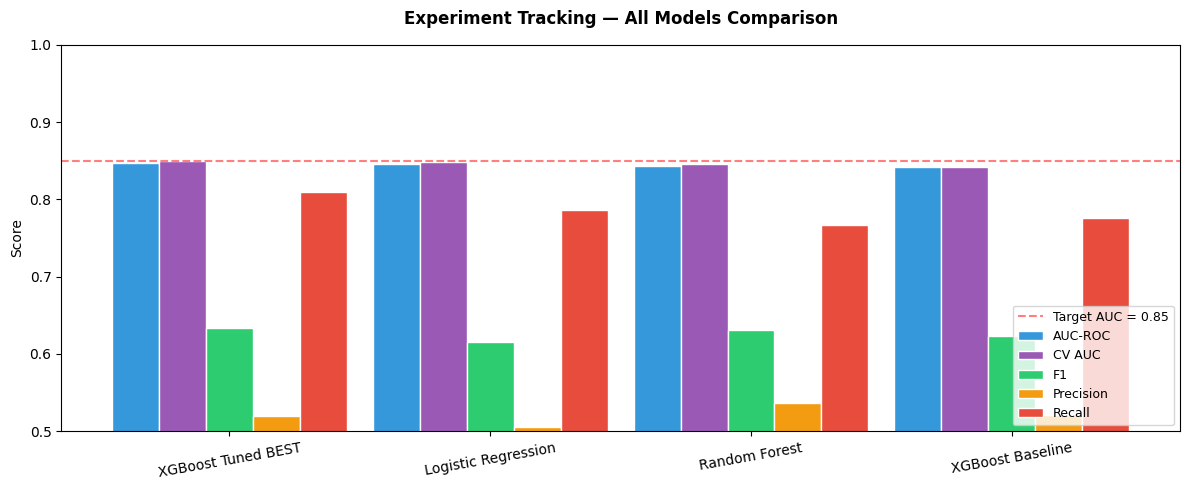

In [6]:
# ============================================================
# EXPERIMENT COMPARISON CHART
# ============================================================

results_df = pd.DataFrame([{
    'Model'    : r['name'].replace('_', ' '),
    'AUC-ROC'  : r['auc_roc'],
    'F1'       : r['f1_score'],
    'Precision': r['precision'],
    'Recall'   : r['recall'],
    'CV AUC'   : r['cv_auc']
} for r in all_results]).sort_values('AUC-ROC', ascending=False)

print(results_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
x   = range(len(results_df))
w   = 0.18

ax.bar([i - w*2   for i in x], results_df['AUC-ROC'],
       w, label='AUC-ROC',   color='#3498db', edgecolor='white')
ax.bar([i - w     for i in x], results_df['CV AUC'],
       w, label='CV AUC',    color='#9b59b6', edgecolor='white')
ax.bar([i         for i in x], results_df['F1'],
       w, label='F1',        color='#2ecc71', edgecolor='white')
ax.bar([i + w     for i in x], results_df['Precision'],
       w, label='Precision', color='#f39c12', edgecolor='white')
ax.bar([i + w*2   for i in x], results_df['Recall'],
       w, label='Recall',    color='#e74c3c', edgecolor='white')

ax.set_xticks(list(x))
ax.set_xticklabels(results_df['Model'], rotation=10)
ax.set_title('Experiment Tracking — All Models Comparison',
             fontweight='bold', pad=15)
ax.set_ylabel('Score')
ax.set_ylim(0.5, 1.0)
ax.axhline(y=0.85, color='red', linestyle='--',
           alpha=0.5, label='Target AUC = 0.85')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/figures/16_experiment_comparison.png',
            bbox_inches='tight')
plt.show()

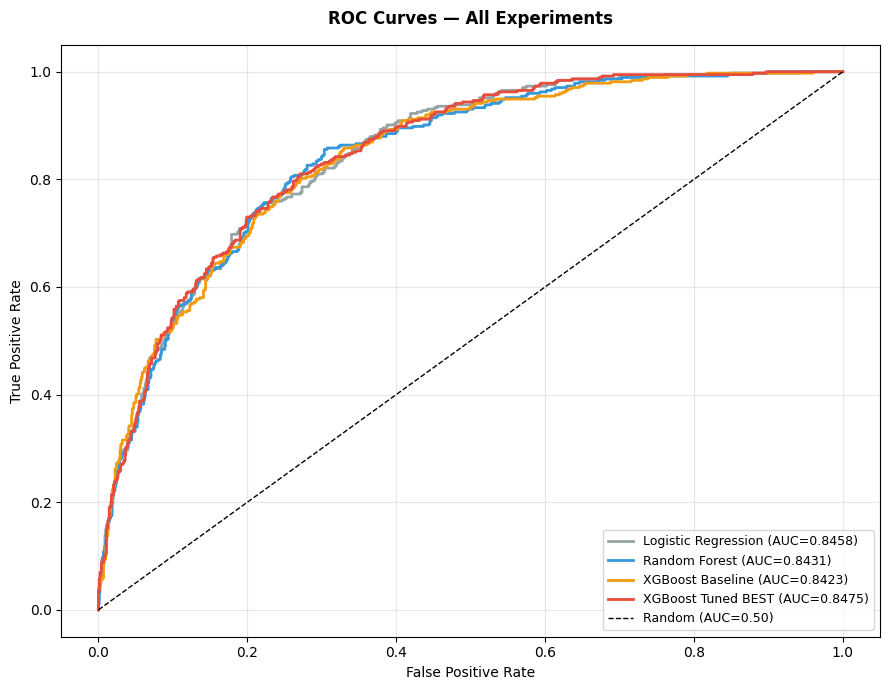

In [7]:
# ============================================================
# ROC CURVES — All models on one chart
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#95a5a6', '#3498db', '#f39c12', '#e74c3c']

for result, color in zip(all_results, colors):
    fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{result['name'].replace('_',' ')} "
                  f"(AUC={result['auc_roc']})")

ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random (AUC=0.50)')
ax.set_title('ROC Curves — All Experiments', fontweight='bold', pad=15)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/17_roc_all_models.png', bbox_inches='tight')
plt.show()

In [8]:
# ============================================================
# SAVE BEST MODEL FOR DEPLOYMENT
# ============================================================

# Get best model object from all_results
best_run_name = tracker.get_best_run('auc_roc')['run_name']
best_result   = next(r for r in all_results if r['name'] == best_run_name)
best_model    = best_result['model']

# Save
joblib.dump(best_model, '../models/final_model.pkl')

# Save metadata
deploy_metadata = {
    'model_name'     : best_run_name,
    'auc_roc'        : best_result['auc_roc'],
    'f1_score'       : best_result['f1_score'],
    'precision'      : best_result['precision'],
    'recall'         : best_result['recall'],
    'threshold'      : 0.4,
    'feature_count'  : X_train.shape[1],
    'features'       : X_train.columns.tolist()
}

with open('../models/deploy_metadata.json', 'w') as f:
    json.dump(deploy_metadata, f, indent=2)

print(f"Best model  : {best_run_name}")
print(f"AUC-ROC     : {best_result['auc_roc']}")
print(f"Saved to    : models/final_model.pkl")
print(f"Metadata    : models/deploy_metadata.json")
print("\nReady for Phase 9 — Deployment!")

Best model  : XGBoost_Tuned_BEST
AUC-ROC     : 0.8475
Saved to    : models/final_model.pkl
Metadata    : models/deploy_metadata.json

Ready for Phase 9 — Deployment!


In [9]:
print("""
╔══════════════════════════════════════════════════════════╗
║         PHASE 8 COMPLETE — EXPERIMENT TRACKING           ║
╠══════════════════════════════════════════════════════════╣
║  4 models trained and tracked                            ║
║  Logs saved → experiment_logs/experiment_log.csv         ║
║  All models saved → models/*.pkl                         ║
║  Best model → models/final_model.pkl                     ║
║  Ready for deployment                                    ║
║                                                          ║
║  On your resume, write:                                  ║
║  "Implemented experiment tracking system logging         ║
║   hyperparameters, AUC, F1, Precision and Recall         ║
║   across all model runs for reproducibility"             ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║         PHASE 8 COMPLETE — EXPERIMENT TRACKING           ║
╠══════════════════════════════════════════════════════════╣
║  4 models trained and tracked                            ║
║  Logs saved → experiment_logs/experiment_log.csv         ║
║  All models saved → models/*.pkl                         ║
║  Best model → models/final_model.pkl                     ║
║  Ready for deployment                                    ║
║                                                          ║
║  On your resume, write:                                  ║
║  "Implemented experiment tracking system logging         ║
║   hyperparameters, AUC, F1, Precision and Recall         ║
║   across all model runs for reproducibility"             ║
╚══════════════════════════════════════════════════════════╝

